In [1]:

import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values


In [4]:
# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

In [5]:
# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

In [6]:
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot


In [7]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


/tmp/ipython-input-473047976.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


In [8]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)


In [9]:
X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [10]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [12]:
# ============================================================================
# ResNet Building Blocks
# ============================================================================

def residual_block(x, filters, kernel_size=3, stride=1, dropout=0.3):
    """
    기본 Residual Block

    Args:
        x: 입력 텐서
        filters: 필터 수
        kernel_size: 커널 크기
        stride: 스트라이드
        dropout: Dropout 비율
    """

    shortcut = x

    # First convolution
    out = layers.Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    # Second convolution
    out = layers.Conv1D(filters, kernel_size, strides=1, padding='same')(out)
    out = layers.BatchNormalization()(out)

    # Projection shortcut if needed
    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add shortcut
    out = layers.Add()([out, shortcut])
    out = layers.Activation('relu')(out)
    out = layers.Dropout(dropout)(out)

    return out

In [13]:
def bottleneck_block(x, filters, kernel_size=3, stride=1, dropout=0.3):
    """
    Bottleneck Residual Block (더 깊은 네트워크용)

    1x1 -> 3x3 -> 1x1 구조
    """

    shortcut = x

    # 1x1 convolution (channel reduction)
    out = layers.Conv1D(filters, 1, strides=1, padding='same')(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    # 3x3 convolution
    out = layers.Conv1D(filters, kernel_size, strides=stride, padding='same')(out)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    # 1x1 convolution (channel expansion)
    out = layers.Conv1D(filters * 4, 1, strides=1, padding='same')(out)
    out = layers.BatchNormalization()(out)

    # Projection shortcut if needed
    if stride != 1 or x.shape[-1] != filters * 4:
        shortcut = layers.Conv1D(filters * 4, 1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add shortcut
    out = layers.Add()([out, shortcut])
    out = layers.Activation('relu')(out)
    out = layers.Dropout(dropout)(out)

    return out




In [14]:
# ============================================================================
# ResNet Models
# ============================================================================

def create_resnet18(n_timesteps=128, n_features=9, n_outputs=6):
    """
    ResNet-18 for HAR

    구조:
    - Initial Conv + MaxPool
    - 4개의 residual stage (각 2개 블록)
    - Global Average Pooling
    - Dense layer

    파라미터: ~11M
    예상 정확도: 85~90%
    """

    inputs = layers.Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Stage 1: 64 filters, 2 blocks
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)

    # Stage 2: 128 filters, 2 blocks
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    # Stage 3: 256 filters, 2 blocks
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)

    # Stage 4: 512 filters, 2 blocks
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_outputs, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResNet18_HAR')

    return model



In [15]:
def create_resnet34(n_timesteps=128, n_features=9, n_outputs=6):
    """
    ResNet-34 for HAR

    구조:
    - Initial Conv + MaxPool
    - 4개의 residual stage (3, 4, 6, 3 블록)
    - Global Average Pooling
    - Dense layer

    파라미터: ~21M
    예상 정확도: 87~92%
    """

    inputs = layers.Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Stage 1: 64 filters, 3 blocks
    for _ in range(3):
        x = residual_block(x, 64, stride=1)

    # Stage 2: 128 filters, 4 blocks
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128, stride=1)

    # Stage 3: 256 filters, 6 blocks
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256, stride=1)

    # Stage 4: 512 filters, 3 blocks
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512, stride=1)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_outputs, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResNet34_HAR')

    return model

In [16]:
def create_resnet_lite(n_timesteps=128, n_features=9, n_outputs=6):
    """
    ResNet-Lite for HAR (경량 버전)

    구조:
    - Initial Conv + MaxPool
    - 3개의 residual stage (각 2개 블록)
    - Global Average Pooling
    - Dense layer

    파라미터: ~2M
    예상 정확도: 83~88%
    학습 속도: 가장 빠름
    """

    inputs = layers.Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = layers.Conv1D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Stage 1: 32 filters, 2 blocks
    x = residual_block(x, 32, stride=1, dropout=0.2)
    x = residual_block(x, 32, stride=1, dropout=0.2)

    # Stage 2: 64 filters, 2 blocks
    x = residual_block(x, 64, stride=2, dropout=0.2)
    x = residual_block(x, 64, stride=1, dropout=0.2)

    # Stage 3: 128 filters, 2 blocks
    x = residual_block(x, 128, stride=2, dropout=0.2)
    x = residual_block(x, 128, stride=1, dropout=0.2)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_outputs, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResNet_Lite_HAR')

    return model



In [17]:
def create_resnet50(n_timesteps=128, n_features=9, n_outputs=6):
    """
    ResNet-50 for HAR (Bottleneck 사용)

    구조:
    - Initial Conv + MaxPool
    - 4개의 residual stage (3, 4, 6, 3 bottleneck 블록)
    - Global Average Pooling
    - Dense layer

    파라미터: ~23M
    예상 정확도: 88~93%
    """

    inputs = layers.Input(shape=(n_timesteps, n_features))

    # Initial convolution
    x = layers.Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Stage 1: 64 filters, 3 blocks
    for i in range(3):
        stride = 1 if i > 0 else 1
        x = bottleneck_block(x, 64, stride=stride)

    # Stage 2: 128 filters, 4 blocks
    x = bottleneck_block(x, 128, stride=2)
    for _ in range(3):
        x = bottleneck_block(x, 128, stride=1)

    # Stage 3: 256 filters, 6 blocks
    x = bottleneck_block(x, 256, stride=2)
    for _ in range(5):
        x = bottleneck_block(x, 256, stride=1)

    # Stage 4: 512 filters, 3 blocks
    x = bottleneck_block(x, 512, stride=2)
    for _ in range(2):
        x = bottleneck_block(x, 512, stride=1)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_outputs, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='ResNet50_HAR')

    return model

In [18]:
# ============================================================================
# 통합 함수
# ============================================================================

def create_resnet_model(model_type='resnet18', n_timesteps=128, n_features=9, n_outputs=6):
    """
    ResNet 모델 생성 함수

    Args:
        model_type: 모델 타입
            - 'resnet_lite': 경량 버전 (빠름, 83~88%)
            - 'resnet18': 표준 버전 (추천, 85~90%)
            - 'resnet34': 깊은 버전 (87~92%)
            - 'resnet50': Bottleneck 버전 (88~93%)
        n_timesteps: 시퀀스 길이
        n_features: 입력 특징 수
        n_outputs: 출력 클래스 수

    Returns:
        컴파일된 Keras Model
    """

    # 모델 생성
    if model_type == 'resnet_lite':
        model = create_resnet_lite(n_timesteps, n_features, n_outputs)
        lr = 0.001
    elif model_type == 'resnet18':
        model = create_resnet18(n_timesteps, n_features, n_outputs)
        lr = 0.001
    elif model_type == 'resnet34':
        model = create_resnet34(n_timesteps, n_features, n_outputs)
        lr = 0.0008
    elif model_type == 'resnet50':
        model = create_resnet50(n_timesteps, n_features, n_outputs)
        lr = 0.0005
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # 모델 컴파일
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    return model


In [19]:
def get_callbacks():
    """학습용 Callbacks"""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

In [20]:
model = create_resnet_model('resnet18')
model.summary()


Model: "ResNet18_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 64)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 64)    │     12,352 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 64)    │     12,352 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 64)    │          0 │ batch_normalizat

 Total params: 3,928,326 (14.99 MB)

 Trainable params: 3,918,726 (14.95 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [21]:
callbacks = get_callbacks()

In [29]:
history = model.fit(
    X_train, y_train_one_hot,
    epochs=40,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9666 - loss: 0.0691 - val_accuracy: 0.9769 - val_loss: 0.0552 - learning_rate: 1.2500e-04
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9687 - loss: 0.0781 - val_accuracy: 0.9844 - val_loss: 0.0541 - learning_rate: 1.2500e-04
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9689 - loss: 0.0763 - val_accuracy: 0.9742 - val_loss: 0.0624 - learning_rate: 1.2500e-04
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9628 - loss: 0.0861 - val_accuracy: 0.9796 - val_loss: 0.0602 - learning_rate: 1.2500e-04
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9655 - loss: 0.0781 - val_accuracy: 0.9742 - val_loss: 0.0588 - learning_rate: 1.2500e-04
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9720 - loss: 0.0696 - val_accuracy: 0.9742 - val_loss: 0.0609 - learning_rate: 1.2500e-04
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9676 

In [30]:
test_loss, test_accuracy = model.evaluate(testX, testy_one_hot, verbose=0)

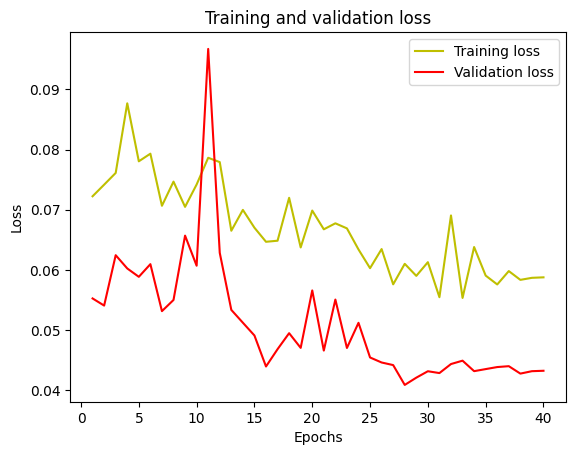

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =history.history['loss']
val_loss =history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

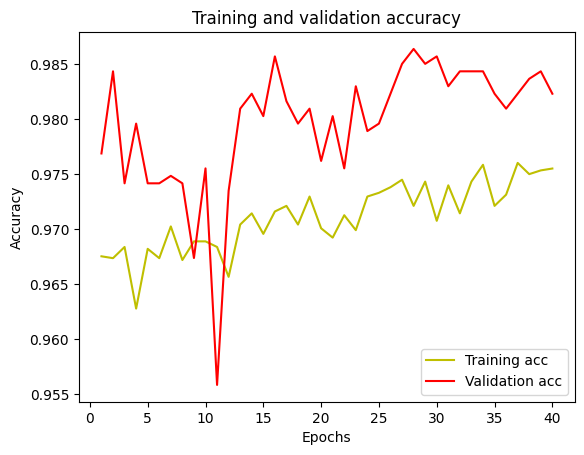

In [32]:


acc =history.history['accuracy']
val_acc =history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [33]:

from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=model.predict(testX)
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[496   0   0   0   0   0]
 [  0 471   0   0   0   0]
 [  0   1 419   0   0   0]
 [  0   3   0 414  68   6]
 [  0   0   0  46 486   0]
 [  0   0   0   0   0 537]]
0.9579233118425518
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       496
           1       0.99      1.00      1.00       471
           2       1.00      1.00      1.00       420
           3       0.90      0.84      0.87       491
           4       0.88      0.91      0.90       532
           5       0.99      1.00      0.99       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



<Axes: >

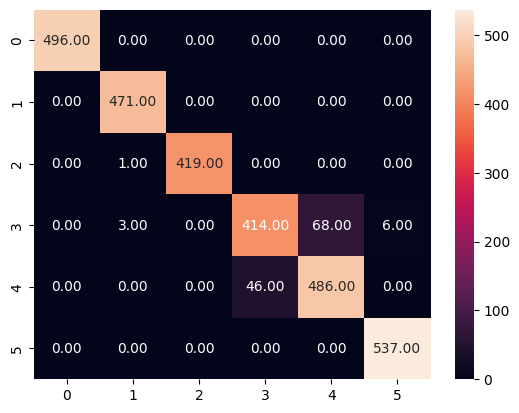

In [34]:
sns.heatmap(cm, annot=True, fmt = '.2f')